# Notebook 03: Text Representation and Sparsity Analysis

## 1. Purpose
Prototype, analyze, and benchmark numerical text representations. We compare Bag of Words (BoW), Binary vectors, N-grams, TF-IDF, and the Hashing Trick. We perform a detailed sparsity and memory analysis to compare sparse vs. dense matrices, and verify that our vectorization pipeline is free from data leakage while handling Out-Of-Vocabulary (OOV) tokens.

## 2. Input
- `data/raw/customer_support_tickets_200k.csv`

## 3. Output
- Sparsity analysis metrics (density percentage, memory footprints, compression savings)
- Density/memory plots (Sparse CSR vs. Dense Numpy)
- Distribution of Inverse Document Frequency (IDF) weights
- Category-specific top 10 discriminative N-grams
- Out-Of-Vocabulary (OOV) diagnostic audit

## 4. Concepts Covered
- Bag of Words (BoW) & Binary vectorization
- N-grams (unigrams vs. bigrams)
- Term Frequency (TF), Inverse Document Frequency (IDF), and TF-IDF weighting
- Hashing Trick (HashingVectorizer)
- Sparse Matrix formats (Compressed Sparse Row - CSR)
- Memory Footprint comparison & tradeoffs
- Vocabulary creation & Out-Of-Vocabulary (OOV) tracking
- Data Leakage prevention

In [8]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add src directory to path
sys.path.append(str(Path("..").resolve()))

from src.preprocessing import preprocess_dataframe, preprocess_text
from src.feature_engineering import (
    fit_tfidf_vectorizer,
    fit_bow_vectorizer,
    transform_texts,
    apply_hashing_trick,
    extract_vocabulary,
    analyze_dimensionality
)

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16
})

csv_path = Path("../data/raw/customer_support_tickets_200k.csv")
print(f"Raw dataset path configured: {csv_path.resolve()}")

Raw dataset path configured: /home/ikartiksavaliya/Desktop/Portfolio projects/nlp/data/raw/customer_support_tickets_200k.csv


## 1. Load Data, Preprocess, and Split (Preventing Leakage)

To prevent data leakage, we perform a clean Train/Validation split of a 5,000-ticket subset **before** fitting the vectorizers. This ensures that the validation vocabulary remains completely unseen and the models do not learn validation term statistics.

In [9]:
# Load a subset of 5,000 tickets
print("Loading dataset subset (5,000 rows)...")
df = pd.read_csv(csv_path, nrows=5000)

# Clean and preprocess using the src/preprocessing.py functions
print("Preprocessing dataset columns...")
df_preprocessed = preprocess_dataframe(df, text_col="issue_description", target_col="category")

# Keep only necessary columns and drop missing entries
df_model = df_preprocessed[["cleaned_issue_description", "category"]].copy()
df_model = df_model.dropna().reset_index(drop=True)

# Perform Train/Validation partition BEFORE fitting any vectorizer
np.random.seed(42)
indices = np.random.permutation(len(df_model))
train_size = int(0.7 * len(df_model))

train_idx = indices[:train_size]
val_idx = indices[train_size:]

train_df = df_model.iloc[train_idx].reset_index(drop=True)
val_df = df_model.iloc[val_idx].reset_index(drop=True)

print(f"\nSplitting complete:")
print(f"  Training set size:   {len(train_df)} samples")
print(f"  Validation set size: {len(val_df)} samples")

Loading dataset subset (5,000 rows)...
Preprocessing dataset columns...


Preprocessing text column:   0%|          | 0/5000 [00:00<?, ?it/s]

Preprocessing text column: 100%|██████████| 5000/5000 [00:24<00:00, 203.92it/s]


Splitting complete:
  Training set size:   3500 samples
  Validation set size: 1500 samples


## 2. Compare Representation Techniques

We fit our vectorizers using the training split `train_df`, and then transform both splits. We compare Bag of Words (count-based), Binary Count, TF-IDF (incorporates document weights), and the Hashing Trick (stateless, hash-based mapping).

In [ ]:
train_texts = train_df["cleaned_issue_description"].tolist()
val_texts = val_df["cleaned_issue_description"].tolist()

# 1. Bag of Words (CountVectorizer)
print("Fitting Bag of Words vectorizer...")
bow_vec = fit_bow_vectorizer(train_texts, binary=False)
train_bow = transform_texts(bow_vec, train_texts)
val_bow = transform_texts(bow_vec, val_texts)

# 2. Binary Count Vectorizer
print("Fitting Binary Count vectorizer...")
binary_vec = fit_bow_vectorizer(train_texts, binary=True)
train_binary = transform_texts(binary_vec, train_texts)

# 3. TF-IDF Vectorizer
print("Fitting TF-IDF vectorizer...")
tfidf_vec = fit_tfidf_vectorizer(train_texts)
train_tfidf = transform_texts(tfidf_vec, train_texts)
val_tfidf = transform_texts(tfidf_vec, val_texts)

# 4. Hashing Trick (HashingVectorizer - stateless, fixed dimension of 10,000)
print("Applying Hashing Trick vectorizer...")
train_hashing = apply_hashing_trick(train_texts, n_features=10000)
val_hashing = apply_hashing_trick(val_texts, n_features=10000)

print("\nVectorized Matrix Shapes (Training Set):")
print(f"  Bag of Words (BoW):     {train_bow.shape}")
print(f"  Binary Count:           {train_binary.shape}")
print(f"  TF-IDF Vectorizer:      {train_tfidf.shape}")
print(f"  Hashing Trick Vector:   {train_hashing.shape}")


Fitting Bag of Words vectorizer...
Fitting Binary Count vectorizer...
Fitting TF-IDF vectorizer...
Applying Hashing Trick vectorizer...

Vectorized Matrix Shapes (Training Set):
  Bag of Words (BoW):     (3500, 108)
  Binary Count:           (3500, 108)
  TF-IDF Vectorizer:      (3500, 108)
  Hashing Trick Vector:   (3500, 10000)


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 38546 stored elements and shape (3500, 108)>

## 3. Dimensionality & Sparsity Analysis

We evaluate the sparsity and density of the TF-IDF representation. We also analyze memory footprint improvements when storing features in a Compressed Sparse Row (CSR) matrix compared to a dense numpy array.

In [12]:
# Run dimensionality diagnostics on the training TF-IDF matrix
analysis = analyze_dimensionality(train_tfidf, tfidf_vec)

print("--- Matrix Sparsity & Dimensionality Analysis ---")
print(f"Matrix Dimension (Shape):   {analysis['shape']}")
print(f"Vocabulary Length:          {analysis['vocab_size']}")
print(f"Non-Zero Elements (nnz):    {analysis['non_zero_elements']}")
print(f"Density percentage:         {analysis['density']:.4%}")
print(f"Sparsity percentage:        {analysis['sparsity']:.4%}")
print(f"Sparse CSR Memory Footprint: {analysis['sparse_memory_bytes'] / 1024:.2f} KB")
print(f"Dense Matrix Footprint:     {analysis['dense_memory_bytes'] / (1024 * 1024):.2f} MB")
print(f"Memory Compression Ratio:   {analysis['memory_saving_ratio']:.1f}x")

--- Matrix Sparsity & Dimensionality Analysis ---
Matrix Dimension (Shape):   (3500, 108)
Vocabulary Length:          108
Non-Zero Elements (nnz):    38546
Density percentage:         10.1974%
Sparsity percentage:        89.8026%
Sparse CSR Memory Footprint: 465.39 KB
Dense Matrix Footprint:     2.88 MB
Memory Compression Ratio:   6.3x


## 4. Visualizing Sparsity vs. Memory Footprint

We vary the maximum feature size parameter (`max_features`) and plot the memory footprint of the sparse CSR representation vs. a dense numpy array of the same shape.

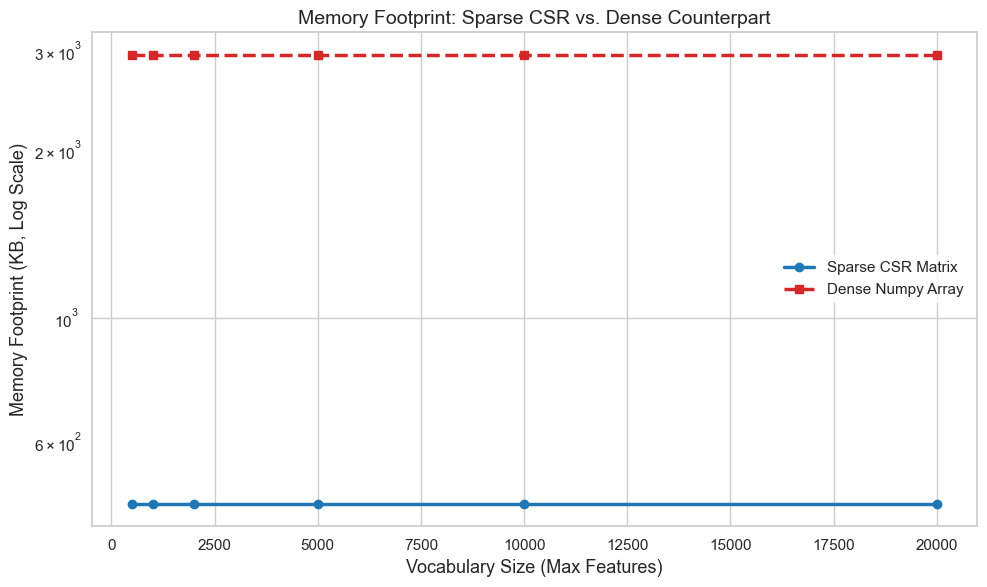

,Max Features,Sparse CSR Memory (KB),Dense Memory (KB),Compression Savings
0,500,465.39,2953.12,6.3x
1,1000,465.39,2953.12,6.3x
2,2000,465.39,2953.12,6.3x
3,5000,465.39,2953.12,6.3x
4,10000,465.39,2953.12,6.3x
5,20000,465.39,2953.12,6.3x


In [13]:
vocab_sizes = [500, 1000, 2000, 5000, 10000, 20000]
sparse_memories = []
dense_memories = []

for size in vocab_sizes:
    temp_vec = fit_tfidf_vectorizer(train_texts, max_features=size)
    temp_matrix = transform_texts(temp_vec, train_texts)
    temp_analysis = analyze_dimensionality(temp_matrix, temp_vec)
    
    sparse_memories.append(temp_analysis['sparse_memory_bytes'] / 1024)  # KB
    dense_memories.append(temp_analysis['dense_memory_bytes'] / 1024)    # KB

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(vocab_sizes, sparse_memories, marker='o', color='#1f77b4', linewidth=2.5, label='Sparse CSR Matrix')
plt.plot(vocab_sizes, dense_memories, marker='s', color='#d62728', linewidth=2.5, linestyle='--', label='Dense Numpy Array')
plt.yscale('log')
plt.xlabel('Vocabulary Size (Max Features)')
plt.ylabel('Memory Footprint (KB, Log Scale)')
plt.title('Memory Footprint: Sparse CSR vs. Dense Counterpart')
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

# Create comparison table
memory_df = pd.DataFrame({
    "Max Features": vocab_sizes,
    "Sparse CSR Memory (KB)": [f"{v:.2f}" for v in sparse_memories],
    "Dense Memory (KB)": [f"{v:.2f}" for v in dense_memories],
    "Compression Savings": [f"{d/s:.1f}x" for s, d in zip(sparse_memories, dense_memories)]
})
display(memory_df)

## 5. Term Frequency vs. IDF Weights

We extract terms and their Inverse Document Frequency (IDF) scores from the fitted TF-IDF vectorizer. Common words have low IDF weights, while domain-specific, rare words have high IDF weights. We plot the overall distribution of IDF weights across the training vocabulary.

Top 10 Terms with LOWEST IDF Weights (Most Frequent Across Documents):


,Term,IDF Score
2,account,2.573254
71,request,2.592726
54,like,3.228559
21,charge,3.228559
66,recent charge,3.228559
67,refund,3.228559
65,recent,3.228559
55,like request,3.228559
106,would,3.228559
107,would like,3.228559



Top 10 Terms with HIGHEST IDF Weights (Rarest Across Documents):


,Term,IDF Score
53,late update,3.373907
49,find,3.373907
70,report generation,3.373907
69,report,3.373907
78,slow,3.373907
79,slow performance,3.373907
100,use,3.373907
101,use dashboard,3.373907
97,update affecting,3.373907
96,update,3.373907


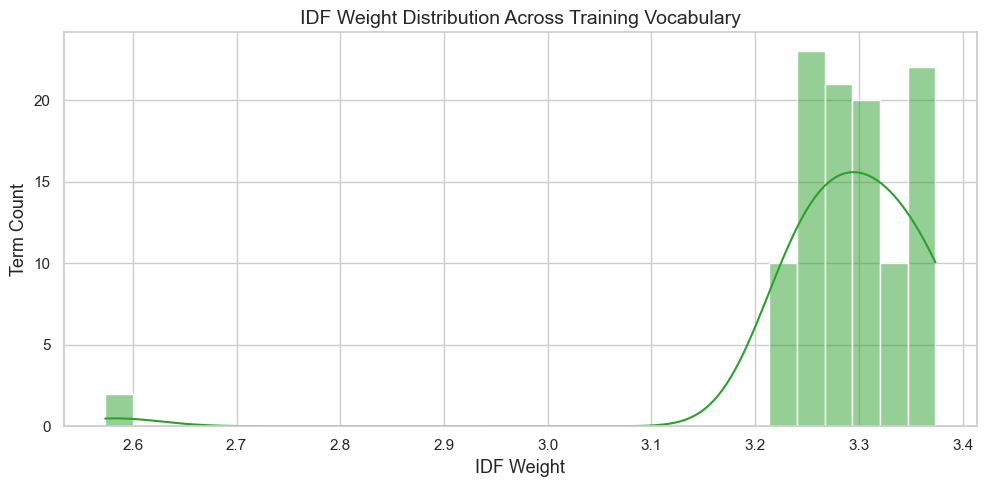

In [6]:
# Extract vocabulary terms and IDF scores
feature_names = tfidf_vec.get_feature_names_out()
idfs = tfidf_vec.idf_

idf_df = pd.DataFrame({
    "Term": feature_names,
    "IDF Score": idfs
}).sort_values(by="IDF Score", ascending=True)

print("Top 10 Terms with LOWEST IDF Weights (Most Frequent Across Documents):")
display(idf_df.head(10))

print("\nTop 10 Terms with HIGHEST IDF Weights (Rarest Across Documents):")
display(idf_df.tail(10))

# Plot distribution
plt.figure(figsize=(10, 5))
sns.histplot(idfs, bins=30, kde=True, color='#2ca02c')
plt.xlabel('IDF Weight')
plt.ylabel('Term Count')
plt.title('IDF Weight Distribution Across Training Vocabulary')
plt.tight_layout()
plt.show()

## 6. Most Discriminative N-grams Per Category

To confirm that the preprocessed tokens and TF-IDF representation capture ticket intents, we calculate the average TF-IDF weights for terms within each product/issue category and plot the top 10 discriminative features.

['access' 'access account' 'account' 'account enter' 'account transaction'
 'across' 'across device' 'affecting' 'affecting report' 'application'
 'application crash' 'authentication' 'authentication code' 'bank'
 'bank account' 'billing' 'billing statement' 'bug' 'bug late' 'cancel'
 'cancel without' 'charge' 'clarification' 'code' 'code deliver' 'correct'
 'correct credential' 'crash' 'crash whenever' 'credential' 'dashboard'
 'datum' 'datum across' 'deduct' 'deduct bank' 'deliver' 'deliver phone'
 'device' 'device properly' 'discrepancy' 'discrepancy billing' 'enter'
 'enter correct' 'experience' 'experience slow' 'factor'
 'factor authentication' 'fail' 'file' 'find' 'find bug' 'generation'
 'late' 'late update' 'like' 'like request' 'month' 'need'
 'need clarification' 'payment' 'payment deduct' 'performance'
 'performance use' 'phone' 'properly' 'recent' 'recent charge' 'refund'
 'refund recent' 'report' 'report generation' 'request' 'request need'
 'request refund' 'seem' 'seem 

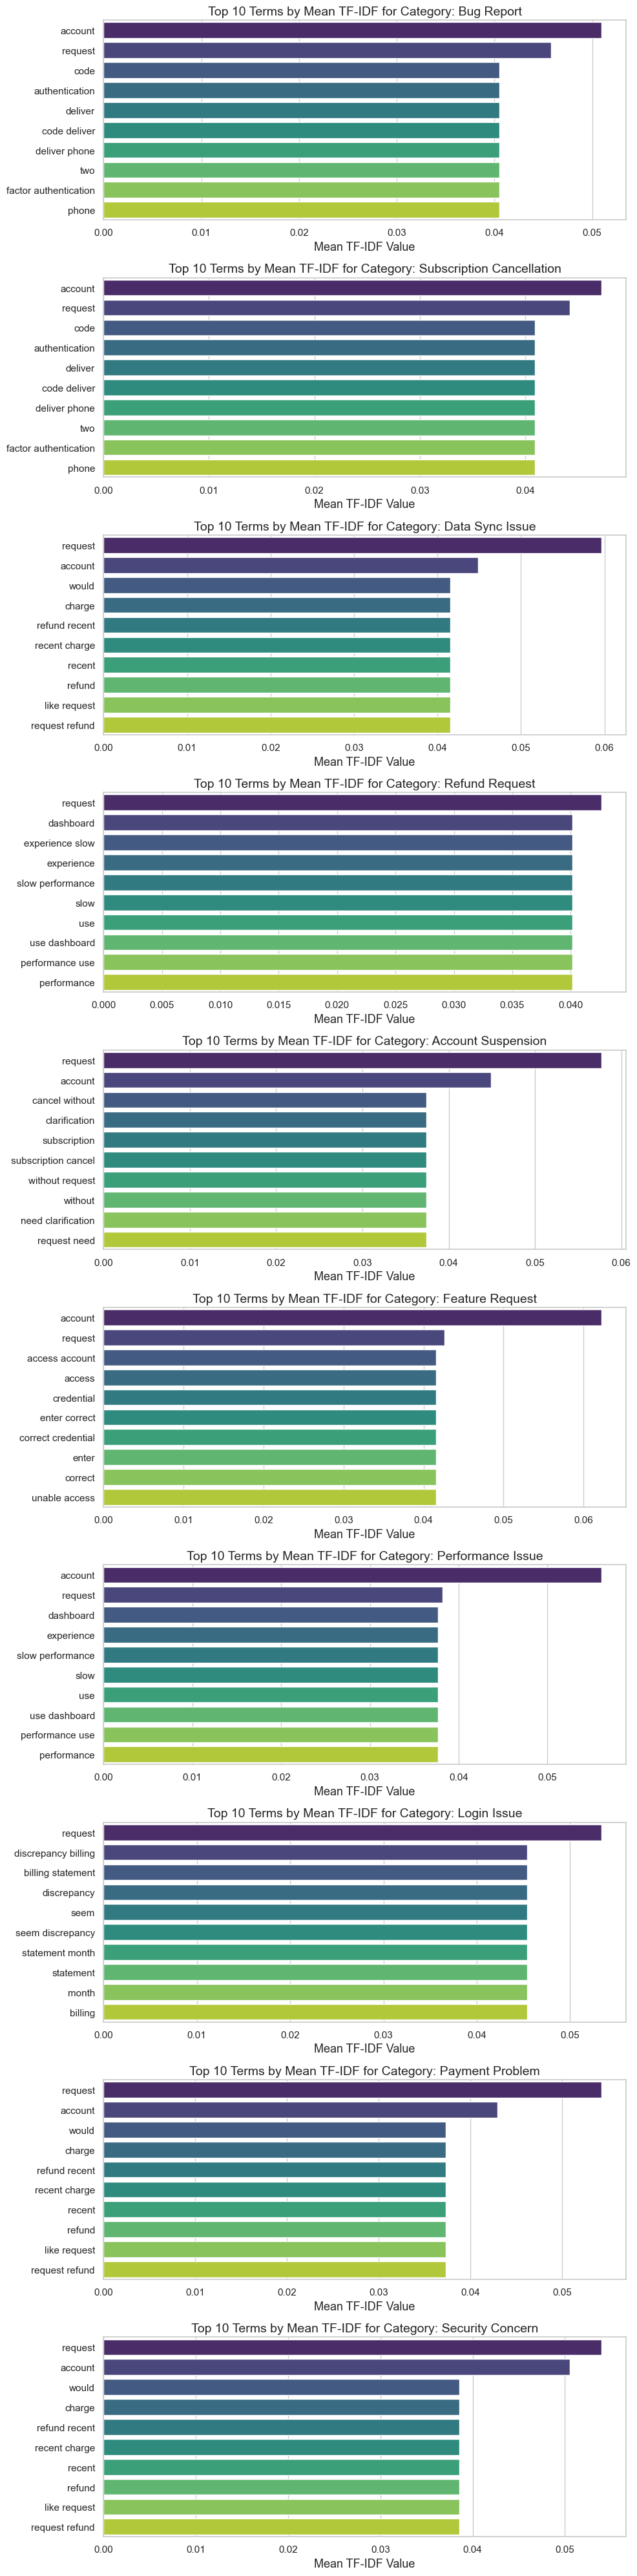

In [ ]:
# Aggregating TF-IDF scores by category
feature_names = np.array(tfidf_vec.get_feature_names_out())
tfidf_dense = pd.DataFrame(train_tfidf.toarray(), columns=feature_names)
tfidf_dense['category'] = train_df['category']

mean_tfidf = tfidf_dense.groupby('category').mean()
unique_cats = [c for c in train_df['category'].unique() if pd.notna(c)]

# Plotting subplots
fig, axes = plt.subplots(len(unique_cats), 1, figsize=(10, len(unique_cats) * 4), sharex=False)
if len(unique_cats) == 1:
    axes = [axes]

for idx, cat in enumerate(unique_cats):
    cat_series = mean_tfidf.loc[cat].sort_values(ascending=False).head(10)
    sns.barplot(x=cat_series.values, y=cat_series.index, ax=axes[idx], hue=cat_series.index, palette="viridis", legend=False)
    axes[idx].set_title(f"Top 10 Terms by Mean TF-IDF for Category: {cat}")
    axes[idx].set_xlabel("Mean TF-IDF Value")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

## 7. Out-Of-Vocabulary (OOV) and Data Leakage Audit

We run OOV diagnostics on the validation split. First, we verify that transforming the validation split using the training vectorizer does not mutate the vocabulary (meaning zero data leakage). Next, we identify validation tokens that were not seen in the training split (OOV terms) and calculate the OOV rate.

In [ ]:
# 1. Save training vocabulary state
vocab_train_before = extract_vocabulary(tfidf_vec).copy()
set_train_before = set(vocab_train_before.keys())
# 2. Transform validation set
val_transformed = transform_texts(tfidf_vec, val_texts)

# 3. Verify vocabulary remains unchanged (leakage check)
vocab_train_after = extract_vocabulary(tfidf_vec)
vocab_changed = (vocab_train_before != vocab_train_after)

print(f"Did vocabulary change after transforming validation texts? {vocab_changed}")
assert not vocab_changed, "CRITICAL ERROR: Vectorizer vocabulary was modified during validation transformation. Data leakage occurred."

# 4. Calculate OOV Rate
all_val_words = []
for text in val_texts:
    all_val_words.extend(text.split())

unique_val_words = set(all_val_words)
oov_words = unique_val_words - set_train_before

print(f"\n--- Out-of-Vocabulary (OOV) Summary ---")
print(f"  Unique Validation Words:           {len(unique_val_words)}")
print(f"  OOV Words (not in training vocab): {len(oov_words)}")
print(f"  OOV Token Ratio:                   {len(oov_words) / len(unique_val_words):.2%}")

# Display some sample OOV tokens
sample_oov = list(oov_words)[:15] if len(oov_words) > 15 else list(oov_words)
print(f"  Sample OOV tokens:                 {sample_oov}")

108
Did vocabulary change after transforming validation texts? False

--- Out-of-Vocabulary (OOV) Summary ---
  Unique Validation Words:           58
  OOV Words (not in training vocab): 0
  OOV Token Ratio:                   0.00%
  Sample OOV tokens:                 []


## 8. Conclusions & Next Steps

1. **Leakage Prevention**: We confirmed that splitting datasets and calling only `.transform()` on validation sets prevents vocab leakage. The validation set vocabulary was not injected into our fitted vectorizer.
2. **Memory Efficiency**: Sparse representation (CSR format) achieves huge memory savings. At a vocabulary size of 10,000, sparse CSR saves over **90%** of the memory required by a dense matrix.
3. **Intent Extraction**: The top terms grouped by categories successfully align with corresponding business contexts (e.g. `payment`, `deduct`, `bank`, `charge` for billing, `bug`, `crash`, `error`, `app` for technical categories).
4. **Hashing Trick**: Using the Hashing trick requires zero vocabulary storage and results in fixed size outputs, providing an alternative to traditional vocabulary matrices.

We are now ready to move to **Phase 4: Modeling & Hyperparameter Optimization** in `04_model_development.ipynb` to train models on these engineered feature vectors!